# Building DB

In [ ]:
# Building a RAG DB
    # - Iterate over the entire dataset scene_graphs
    # - Select the sentences for each region
    # - Filter out the unique ones
    # - Pass these to text_model to get the embeddings
    # - Create dict with sentence and embeddings
    # - Save dict for each region

In [ ]:
import os
import json
from tqdm import tqdm
import pandas as pd

In [ ]:
scene_graph_dir = "/path/to/data/vlm_chest_xray/scene_graphs"
save_dir = "/path/to/data/vlm_chest_xray/"
csv_file = "/path/to/data/vlm_chest_xray/data_split.csv"

In [ ]:
data_split_df = pd.read_csv(csv_file)
print(data_split_df.shape)
data_split_df.head()

In [ ]:
train_list = data_split_df[data_split_df["split"] == "train"]["dicom_id"].tolist()
len(train_list)

In [ ]:
sg_train_list = [f"{scene_graph_dir}/{i}.json" for i in train_list]

len(sg_train_list)

In [ ]:
text_key = 'phrase'
rag_dict = {}

for sg_name in tqdm(sg_train_list[:10]):

    with open(os.path.join(scene_graph_dir, sg_name)) as f:
        sg = json.load(f)

    for object in sg['objects']:
        if object['name'] not in rag_dict.keys():
            rag_dict[object['name']] = [object[text_key]]
        else:
            rag_dict[object['name']] = rag_dict[object['name']] + [object[text_key]]

In [ ]:
# for k, v in rag_dict.items():
#     print(k, len(v))

In [ ]:
# get the unique values for each key in rag_dict
for k, v in rag_dict.items():
    rag_dict[k] = list(set(v))


In [ ]:
for k, v in rag_dict.items():
    print(k, len(v))

In [ ]:
with open(os.path.join(save_dir, "rag_dict.json"), "w") as f:
    json.dump(rag_dict, f)

# Adding Sample Encodings

In [1]:
import os
import json

In [2]:
db_path = "/path/to/data/vlm_chest_xray/rag/text_db_impression.json"

with open(db_path) as f:
    db = json.load(f)
db = {k: sorted(v) for k, v in db.items()}

Abdominal cavity 77
Aortic arch structure 103
Apical zone of left lung 395
Apical zone of right lung 453
Cardiac shadow viewed radiologically;;Heart 2088
Hilar Area of the Left Lung 4067
Hilar Area of the Right Lung 4793
Left clavicle 102
Left hemidiaphragm 161
Left lower lung zone 6268
Left lung 60459
Left mid lung zone 2698
Left upper lung zone 1428
Mediastinum 4331
Right clavicle 100
Right hemidiaphragm 162
Right lower lung zone 6270
Right lung 60125
Right mid lung zone 3012
Right upper lung zone 1797
Structure of carina 17
Superior mediastinum 842
Vertebral column 119
cavoatrial 44
left costophrenic sulcus;;Left costodiaphragmatic recess 845
right costophrenic sulcus;;Right costodiaphragmatic recess 876


Text(0.5, 1.0, 'RAG DB size for each object')

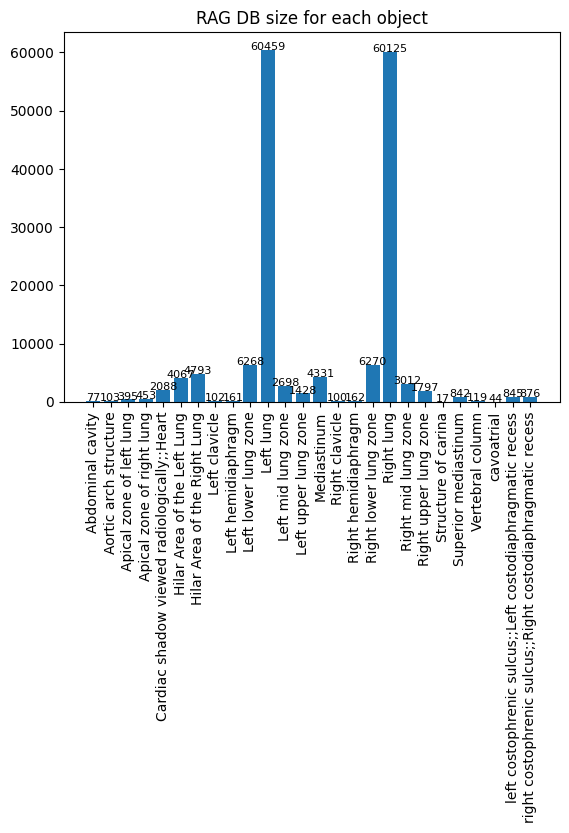

In [3]:
count = {k:len(v) for k, v in db.items() if len(v) > 1}
count = {k: count[k] for k in sorted(count.keys())}

for k, v in count.items():
    print(k, v)


import matplotlib.pyplot as plt

plt.bar(count.keys(), count.values())
# put number on top of the bars
for i in range(len(count)):
    plt.text(i, count[list(count.keys())[i]], count[list(count.keys())[i]], ha='center', fontsize=8)
# values in vertical text
plt.xticks(rotation=90);
plt.title("RAG DB size for each object")

In [16]:
from tqdm import tqdm
import torch

emb_db = {}

# iterate over keys
# get the list of sentences
# pass them to text_model
# save the embeddings in the dict

for k, v in db.items():
    obj_text_emb = [] 
    for text in tqdm(v):
        t_enc = torch.rand(32)
        obj_text_emb.append(t_enc) # replace with actual text_model output
    emb_db[k] = torch.stack(obj_text_emb)

100%|██████████| 1/1 [00:00<00:00, 4766.25it/s]


In [46]:
[k for k, v in db.items() if len(v) == 1]

['right cardiophrenic sulcus',
 'Trachea&&Main Bronchus',
 'Superior vena cava structure',
 'Structure of left margin of heart',
 'Right border of heart viewed radiologically',
 'Right atrial structure',
 'Descending aorta',
 'Structure of left upper quadrant of abdomen',
 'Structure of right upper quadrant of abdomen',
 'left cardiophrenic sulcus']

In [17]:
for k, v in emb_db.items():
    print(k, v.shape)

Right lung torch.Size([60125, 32])
Right upper lung zone torch.Size([1797, 32])
Right mid lung zone torch.Size([3012, 32])
Right lower lung zone torch.Size([6270, 32])
Hilar Area of the Right Lung torch.Size([4793, 32])
Apical zone of right lung torch.Size([453, 32])
right costophrenic sulcus;;Right costodiaphragmatic recess torch.Size([876, 32])
right cardiophrenic sulcus torch.Size([1, 32])
Right hemidiaphragm torch.Size([162, 32])
Left lung torch.Size([60459, 32])
Left upper lung zone torch.Size([1428, 32])
Left mid lung zone torch.Size([2698, 32])
Left lower lung zone torch.Size([6268, 32])
Hilar Area of the Left Lung torch.Size([4067, 32])
Apical zone of left lung torch.Size([395, 32])
left costophrenic sulcus;;Left costodiaphragmatic recess torch.Size([845, 32])
Left hemidiaphragm torch.Size([161, 32])
Trachea&&Main Bronchus torch.Size([1, 32])
Vertebral column torch.Size([119, 32])
Right clavicle torch.Size([100, 32])
Left clavicle torch.Size([102, 32])
Aortic arch structure tor

In [19]:
rag_dir = "/path/to/data/vlm_chest_xray/rag"
torch.save(emb_db, os.path.join(rag_dir, "emb_db_impression.pt"))

In [20]:
# Retrieval:
# - Required: object name or id, quer-embedding
# - Find the best match based on cosine similarity
# - Return the text for top k matches


obj_name = "Right lung"
emb_idx = 20
obj_emb = emb_db[obj_name]
image_emb = obj_emb[emb_idx]
image_emb

tensor([0.5850, 0.4117, 0.3790, 0.7170, 0.9387, 0.8443, 0.2040, 0.2331, 0.9820,
        0.0216, 0.5507, 0.9372, 0.6383, 0.7172, 0.1063, 0.8203, 0.6394, 0.3949,
        0.9344, 0.4470, 0.1084, 0.3971, 0.1752, 0.8747, 0.1059, 0.0760, 0.3674,
        0.3880, 0.6858, 0.0010, 0.7141, 0.4824])

In [32]:
# consine similarity
import torch.nn.functional as F

def get_match(image_emb, obj_emb, top_k=5):

    """
    Get the top k matches based on cosine similarity
    
    Args:
        - image_emb: torch.tensor
        - obj_emb: torch.tensor
        - top_k: int

    Returns:
        - max_val: torch.tensor
        - max_idx: torch.tensor

    """

    similarity = F.cosine_similarity(image_emb, obj_emb)
    max_val, max_idx = torch.topk(similarity, top_k)
    return max_val, max_idx


def retrieve_text(object_name, image_embd, emb_db, text_db, top_k=5):
    """
    Retrieve the text for the top k matches based on cosine similarity

    Args:
        - object_name: str
        - image_embd: torch.tensor
        - emb_db: dict
        - text_db: dict
        - top_k: int

    Returns:
        - max_val: torch.tensor
        - text_values: list
        - max_idx: torch
    """
    obj_emb = emb_db[object_name]
    max_val, max_idx = get_match(image_embd, obj_emb, top_k)    
    text_values = [text_db[object_name][midx] for midx in max_idx]

    return max_val, text_values, max_idx

max_val, text_values, max_idx = retrieve_text(obj_name, image_emb, emb_db, db, top_k=2)


# max_val, max_idx = get_match(image_emb, obj_emb, top_k=2)

for idx, midx in enumerate(max_idx):
    print(max_val[idx], db[obj_name][midx])

tensor(1.)  airspace opacity is not observed. atelectasis is observed. lung opacity is observed. pneumonia is not observed. pleural effusion is not observed.
tensor(0.9248)  lung opacity is observed. pulmonary edema/hazy opacity is observed. aspiration is observed. pneumonia is observed. increased reticular markings/ild pattern is observed. pleural effusion is observed. pleural/parenchymal scarring is observed. pleural effusion is not observed. pneumothorax is not observed.


' airspace opacity is not observed. atelectasis is not observed. linear/patchy atelectasis is not observed. lung opacity is not observed. pleural/parenchymal scarring is not observed. lung lesion is not observed. multiple masses/nodules is not observed. pneumonia is not observed. hyperaeration is observed.'

In [23]:
scene_graph_dir = "/path/to/data/vlm_chest_xray/scene_graphs"
len(os.listdir(scene_graph_dir))
# lets find the sg with "Looks abnormal. Looks normal."
# sg_checklist = []

# for sg_name in tqdm(os.listdir(scene_graph_dir)):
#     try:
#         if len(sg_checklist) > 1:
#             break
#         with open(os.path.join(scene_graph_dir, sg_name)) as f:
#             sg = json.load(f)
#             for object in sg['objects']:
#                 if "Looks abnormal" in object['impression'] and "Looks normal" in object['impression']:
#                     sg_checklist.append(sg_name)
#                     break
#     except:
#         continue

243310

In [26]:
original_sg_dir = "/path/to/data/physionet.org/chest-genome/files/chest-imagenome/1.0.0/silver_dataset/scene_graph"
sg_name = os.listdir(scene_graph_dir)[0]
with open(os.path.join(scene_graph_dir, sg_name)) as f:
    sg = json.load(f)

with open(os.path.join(original_sg_dir, f'{sg_name[:-5]}_SceneGraph.json')) as f:
    org_sg = json.load(f)

sg_name

'b3c5931f-27ae0769-81c9b7f9-215c2335-6e5d2f2c.json'

In [27]:
atr = org_sg['attributes'][0]
name = atr['name']
print(name)

for o in sg['objects']:
    if o['name'] == name:
        sg_o = o

Right lung


In [28]:
atr

{'right lung': True,
 'bbox_name': 'right lung',
 'synsets': ['C0225706'],
 'name': 'Right lung',
 'attributes': [['anatomicalfinding|no|consolidation',
   'anatomicalfinding|no|pleural effusion',
   'anatomicalfinding|no|pneumothorax'],
  ['anatomicalfinding|no|pulmonary edema/hazy opacity'],
  ['nlp|no|abnormal', 'nlp|yes|normal']],
 'attributes_ids': [['C0702116;;C0239027',
   'CL545973;;C0032227',
   'C1963215;;C0032326'],
  ['CL542044;;C0034063'],
  ['C0205161', 'C1550457']],
 'phrases': ['No other focal consolidation, pleural effusion or\n pneumothorax.',
  'No evidence of pulmonary edema.',
  'No acute cardiopulmonary process.'],
 'phrase_IDs': ['55942594|8', '55942594|9', '55942594|12'],
 'sections': ['finalreport', 'finalreport', 'finalreport'],
 'comparison_cues': [[], [], []],
 'temporal_cues': [[], [], ['temporal|no|acute']],
 'severity_cues': [[], [], []],
 'texture_cues': [[], [], []],
 'object_id': 'b3c5931f-27ae0769-81c9b7f9-215c2335-6e5d2f2c_right lung'}

In [29]:
sg_o

{'name': 'Right lung',
 'bbox_name': 'right lung',
 'bbox_original': [341, 245, 1555, 2251],
 'h_w': [2006, 1214],
 'impression': ' consolidation is not observed. pleural effusion is not observed. pneumothorax is not observed. pulmonary edema/hazy opacity is not observed.',
 'phrase': 'No other focal consolidation, pleural effusion or pneumothorax. No evidence of pulmonary edema. No acute cardiopulmonary process.',
 'bbox': [114, 169, 521, 841]}

## Creating Embeddings using Text Model

In [1]:
import sys
sys.path.append('../')
import torch
from src.models import build_text_model

/path/to/envs/vlm/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
import argparse

parser = argparse.ArgumentParser()
parser.add_argument('--text_enc_type', default='microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext', type=str, 
                    help="Type of text encoder to use")
parser.add_argument('--cl_loss_coef', default=0.1, type=float, help="Weight for contrastive loss")
parser.add_argument('--cl_loss_norm', action='store_true', help='Normalize contrastive loss GT - Used with self-similarity loss only')
parser.add_argument('--proj_dim', default=32, type=int,
                        help="Size of the embeddings per region for contrastive learning (dimension of the text encoder)")
parser.add_argument('--cl_temp', default=0.07, type=float, help="Temperature for contrastive learning")
parser.add_argument('--self_cl_loss', action='store_true', help='Use self-contrastive loss')
args, _ = parser.parse_known_args() 


In [3]:
text_model = build_text_model(args)

In [4]:
text_model.cl_temp

Parameter containing:
tensor(2.6593, requires_grad=True)

In [5]:
ckpt_path = "/path/to/anatomix/outputs/apm_no_label_loss_cl01/last_checkpoint.pth"

In [6]:
model_ckpt = torch.load(ckpt_path, map_location='cpu')['model']

/tmp/ipykernel_629441/3885620084.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_ckpt = torch.load(ckpt_path, map_location='cpu')['model']


In [ ]:
# filter out the text model state_dict
# make sure to remove the prefix 'text_model.'
text_model_ckpt = {k.replace('text_model.', ''): v for k, v in model_ckpt.items() if 'text_model' in k}


In [8]:
text_model.load_state_dict(text_model_ckpt)

<All keys matched successfully>

In [9]:
text_model.cl_temp

Parameter containing:
tensor(-1.7893, requires_grad=True)

In [10]:
import json

text_db_path = "/path/to/data/vlm_chest_xray/rag/text_db_impression.json"

with open(text_db_path) as f:
    text_db = json.load(f)

In [16]:
text_db.keys()

dict_keys(['Right lung', 'Right upper lung zone', 'Right mid lung zone', 'Right lower lung zone', 'Hilar Area of the Right Lung', 'Apical zone of right lung', 'right costophrenic sulcus;;Right costodiaphragmatic recess', 'right cardiophrenic sulcus', 'Right hemidiaphragm', 'Left lung', 'Left upper lung zone', 'Left mid lung zone', 'Left lower lung zone', 'Hilar Area of the Left Lung', 'Apical zone of left lung', 'left costophrenic sulcus;;Left costodiaphragmatic recess', 'Left hemidiaphragm', 'Trachea&&Main Bronchus', 'Vertebral column', 'Right clavicle', 'Left clavicle', 'Aortic arch structure', 'Mediastinum', 'Superior mediastinum', 'Superior vena cava structure', 'Cardiac shadow viewed radiologically;;Heart', 'Structure of left margin of heart', 'Right border of heart viewed radiologically', 'cavoatrial', 'Right atrial structure', 'Descending aorta', 'Structure of carina', 'Structure of left upper quadrant of abdomen', 'Structure of right upper quadrant of abdomen', 'Abdominal cavit

In [17]:
from tqdm import tqdm

In [33]:
def get_embeddings(text_db, text_model, text_key='impression'):
    emb_db = {}
    for k, v in text_db.items():
        obj_text_emb = [] 
        for text in tqdm(v):
            text_tokens = text_model.tokenize([text]).to(text_model.model.device)
            t_enc = text_model(text_tokens.input_ids, text_tokens.attention_mask)['project']
            obj_text_emb.append(t_enc[0]) 
            break
        emb_db[k] = torch.stack(obj_text_emb)
    return emb_db

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
text_model.to(device)
text_model.eval()
with torch.no_grad():
    emb_db = get_embeddings(text_db, text_model)

  0%|          | 0/1 [00:00<?, ?it/s]


# Retrievel Results

In [26]:
import os
import matplotlib.pyplot as plt
import pandas as pd

In [27]:
rag_dir = "/path/to/data/vlm_chest_xray/rag"
experiment_name = "apm_no_label_loss_cl01"
epoch = 29

rag_results_dir = os.path.join(rag_dir, f'{experiment_name}/epoch_{epoch}')
results_csvs = [f for f in os.listdir(rag_results_dir) if f.endswith('.csv')]

In [32]:
import os
import json
# filter out the ones that have > items in the DB
db_path = "/path/to/data/vlm_chest_xray/rag/text_db_impression.json"

with open(db_path) as f:
    db = json.load(f)
db = {k: db[k] for k in sorted(db.keys())}
count = {k:len(v) for k, v in db.items() if len(v) > 1}
# count = {k: count[k] for k in sorted(count.keys())}
more_than_one = count.keys()
print(len(more_than_one))


26


26


Text(0.5, 1.0, 'RAG DB size for each object')

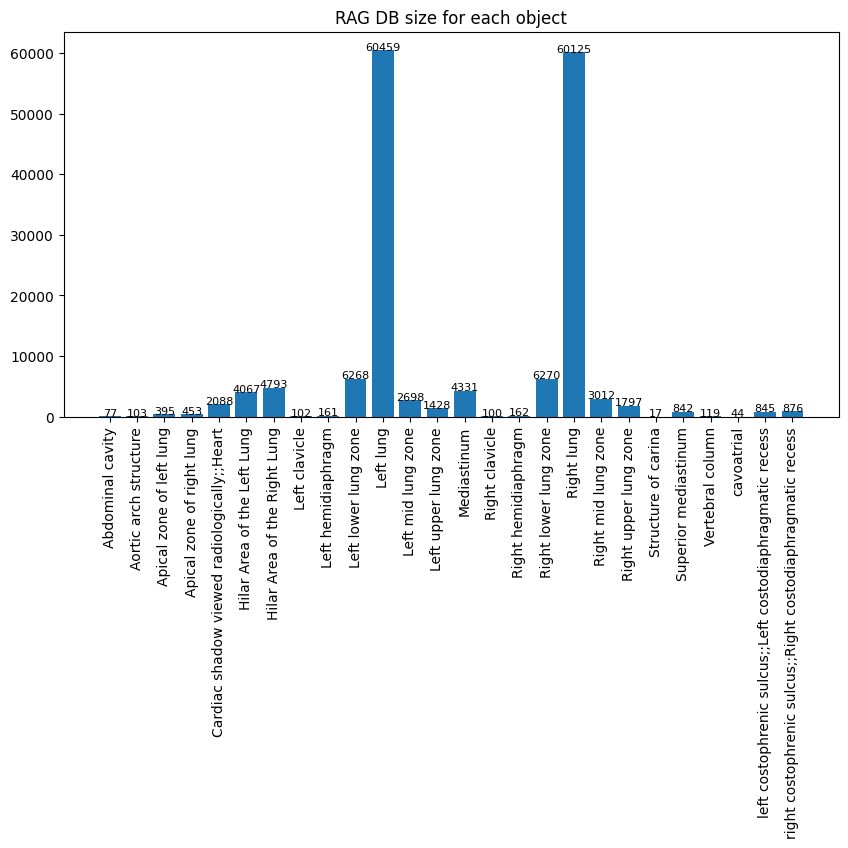

In [33]:
plt.figure(figsize=(10, 5))
plt.bar(count.keys(), count.values())
print(len(count))
# put number on top of the bars
for i in range(len(count)):
    plt.text(i, count[list(count.keys())[i]], count[list(count.keys())[i]], ha='center', fontsize=8)
# values in vertical text
plt.xticks(rotation=90);
plt.title("RAG DB size for each object")


In [4]:
results_csvs

['test_top_4_results.csv',
 'val_top_1_results.csv',
 'test_top_2_results.csv',
 'val_top_4_results.csv',
 'test_top_1_results.csv',
 'val_top_2_results.csv',
 'test_top_3_results.csv',
 'test_top_5_results.csv',
 'val_top_5_results.csv',
 'val_top_3_results.csv']

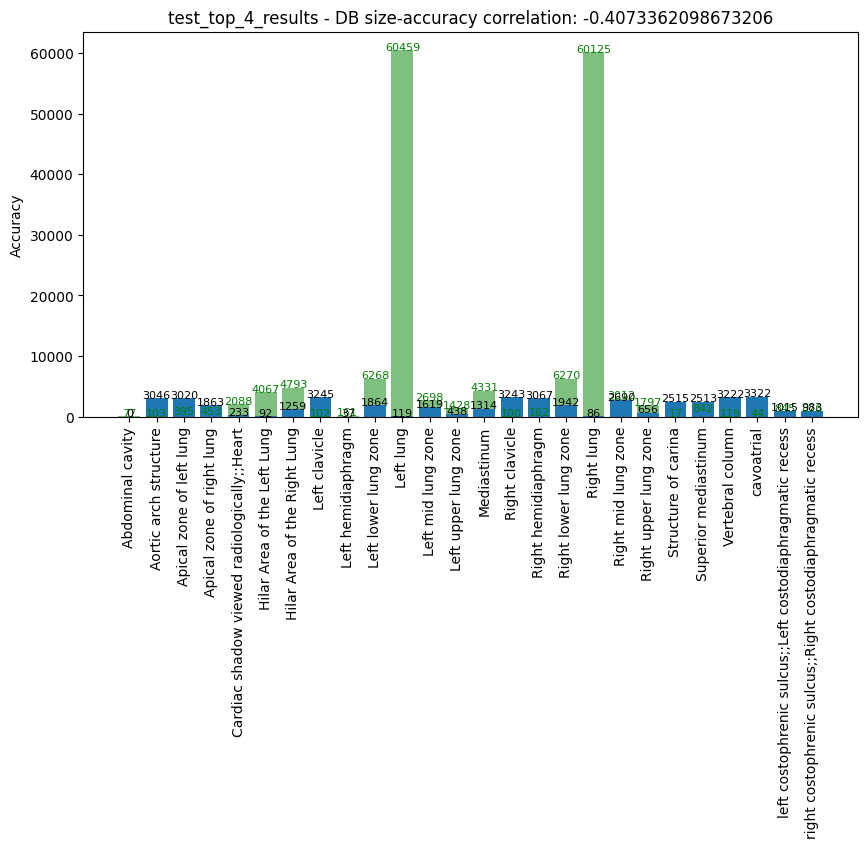

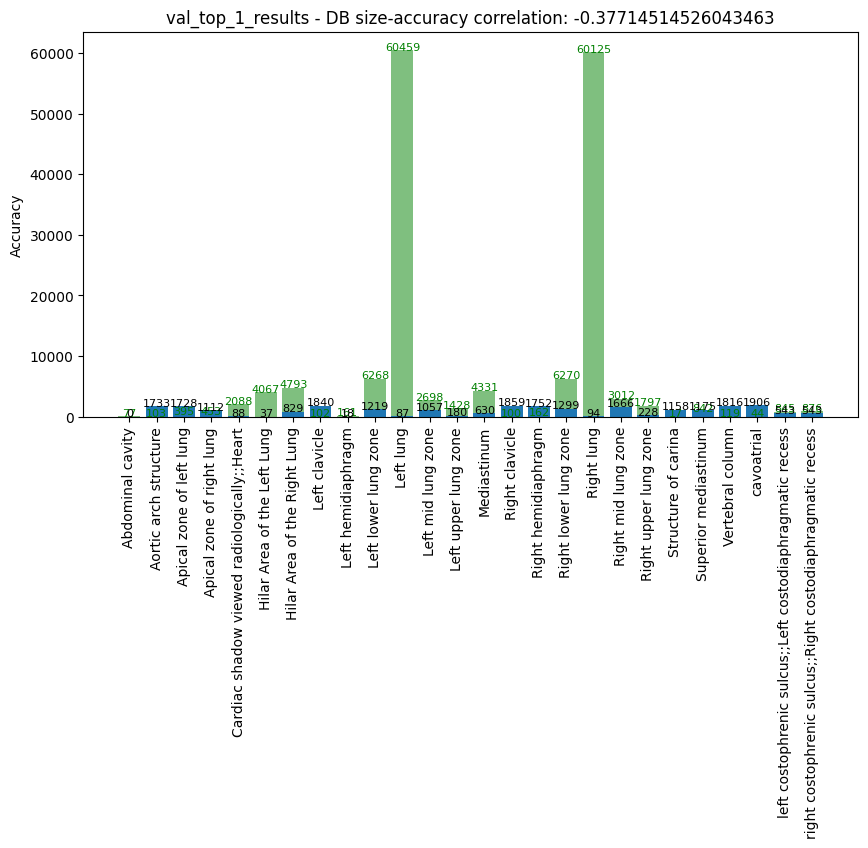

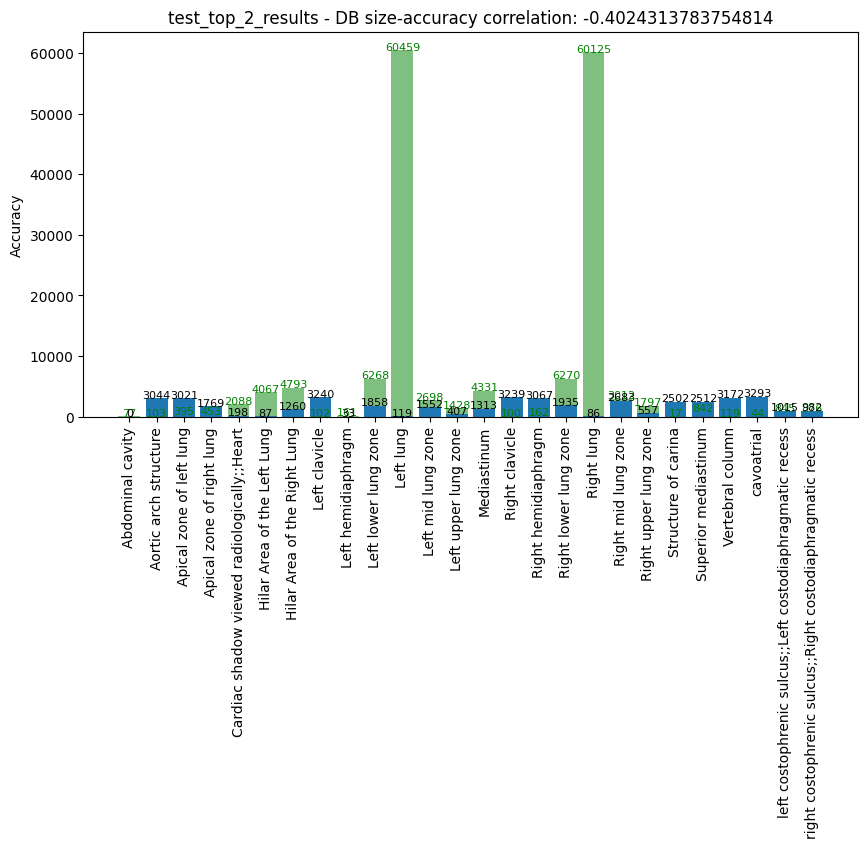

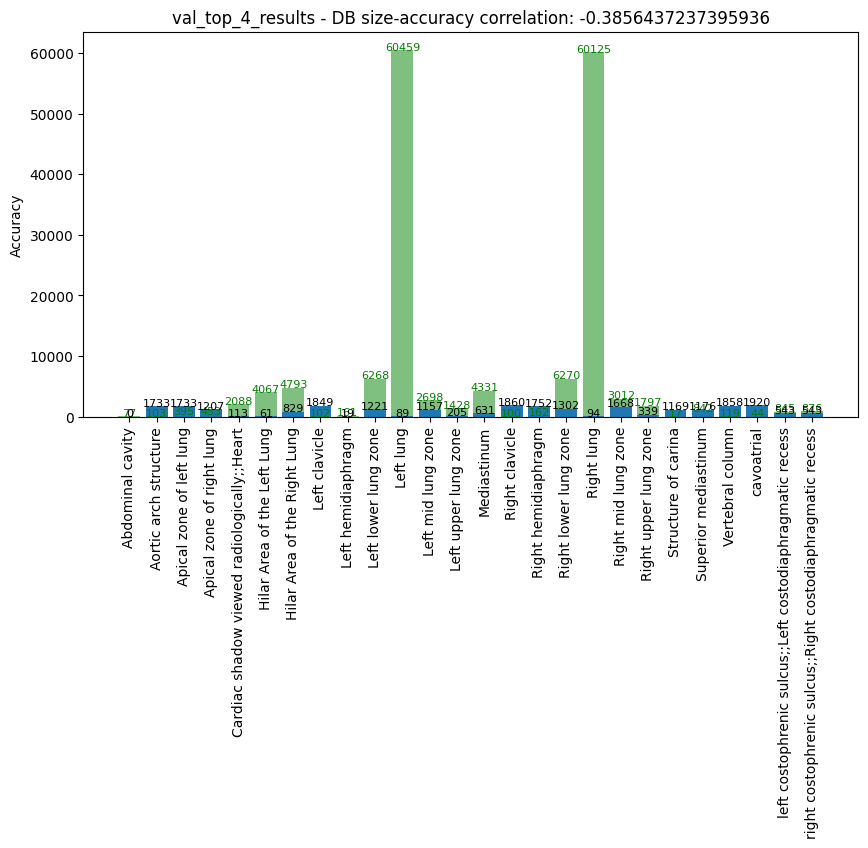

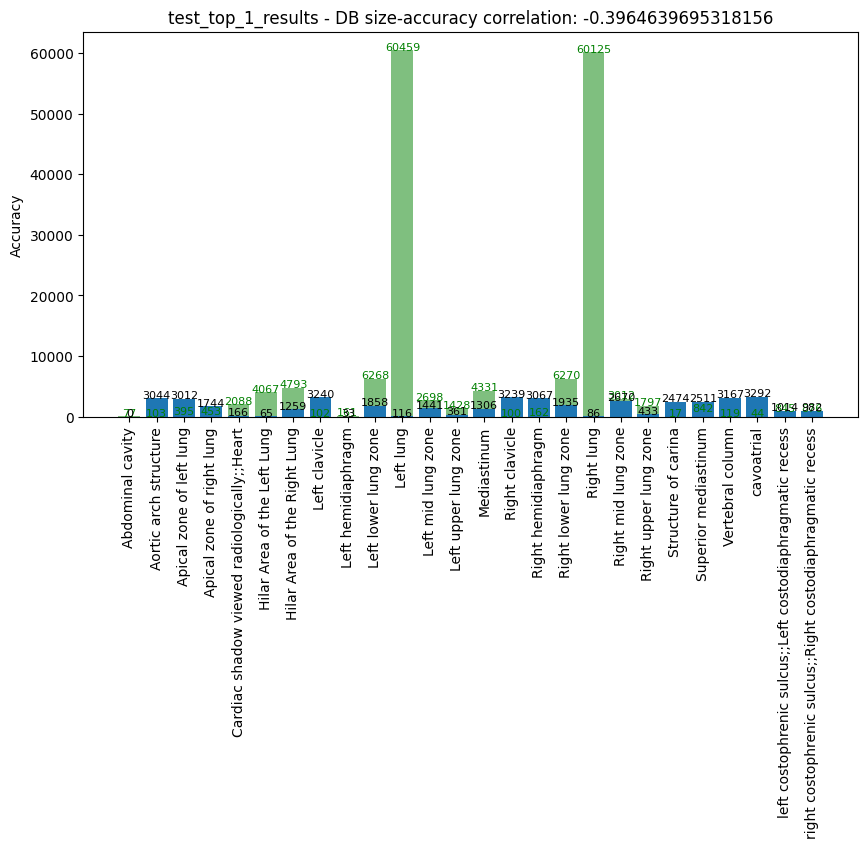

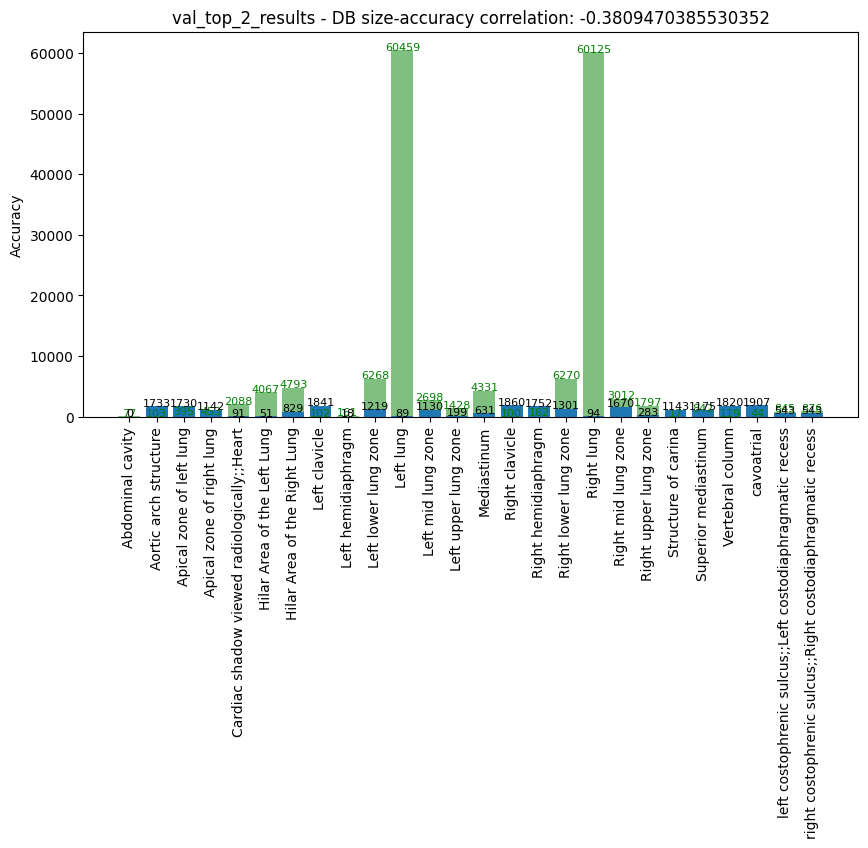

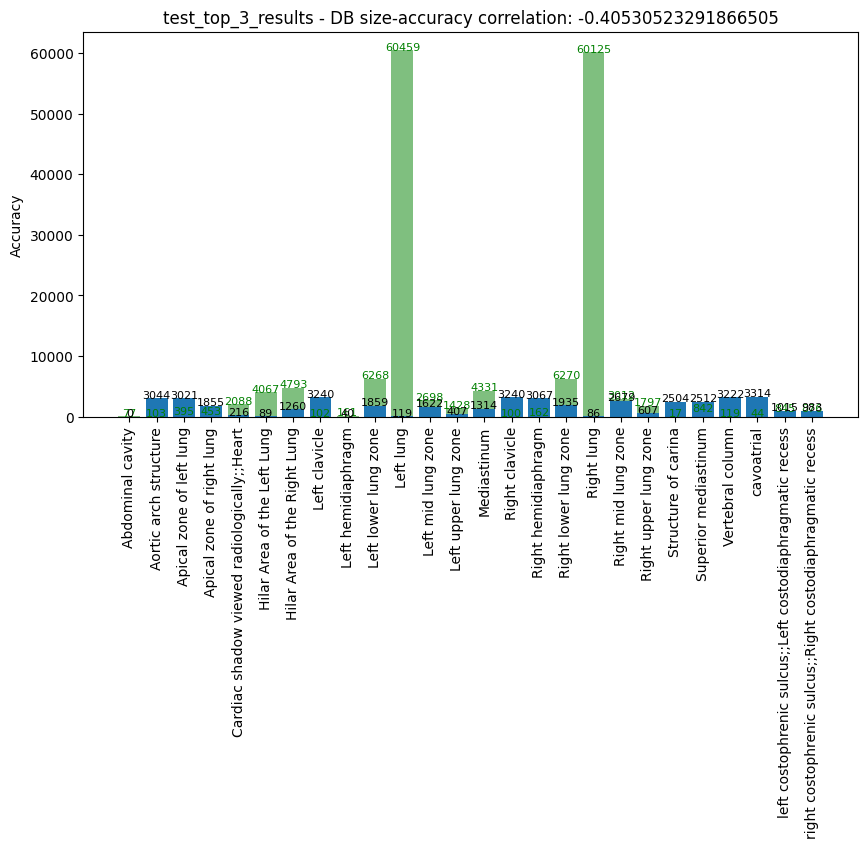

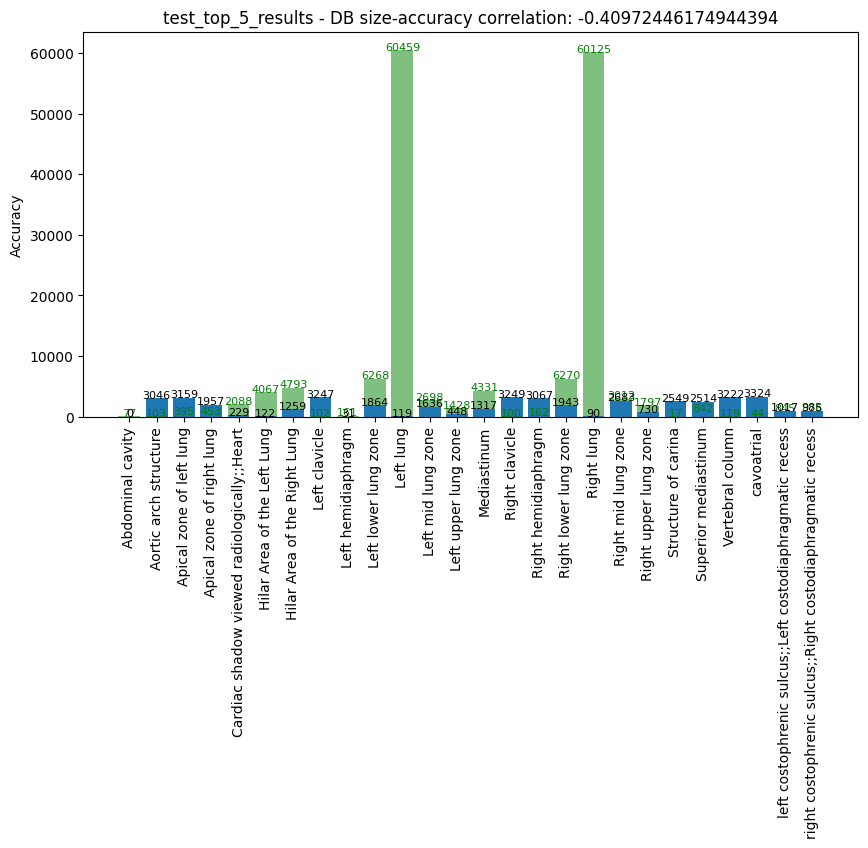

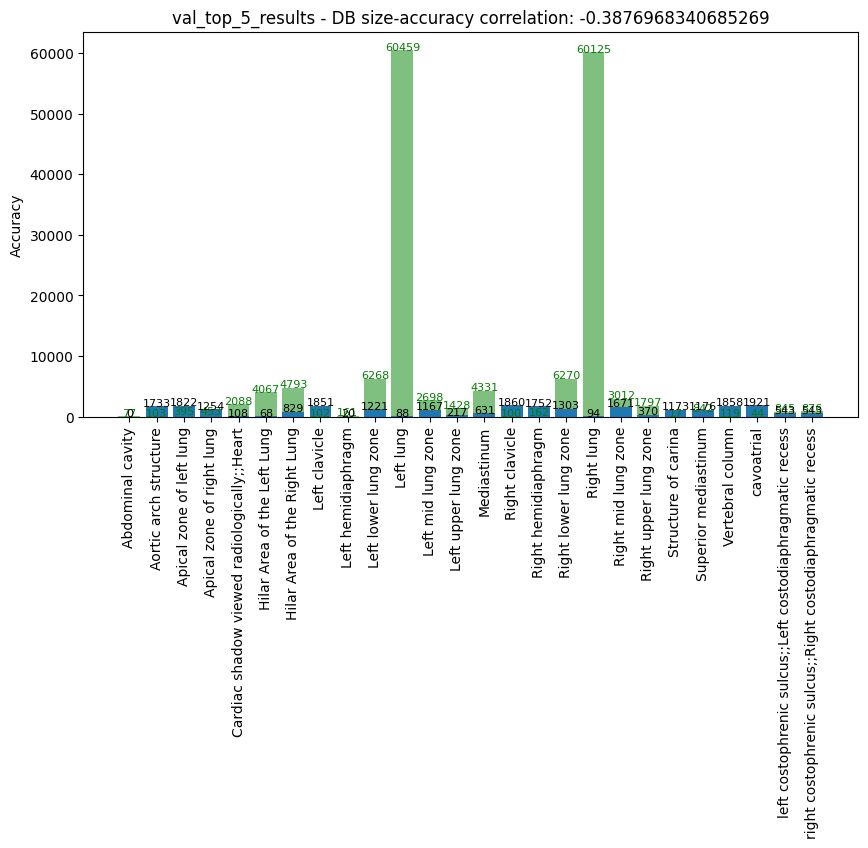

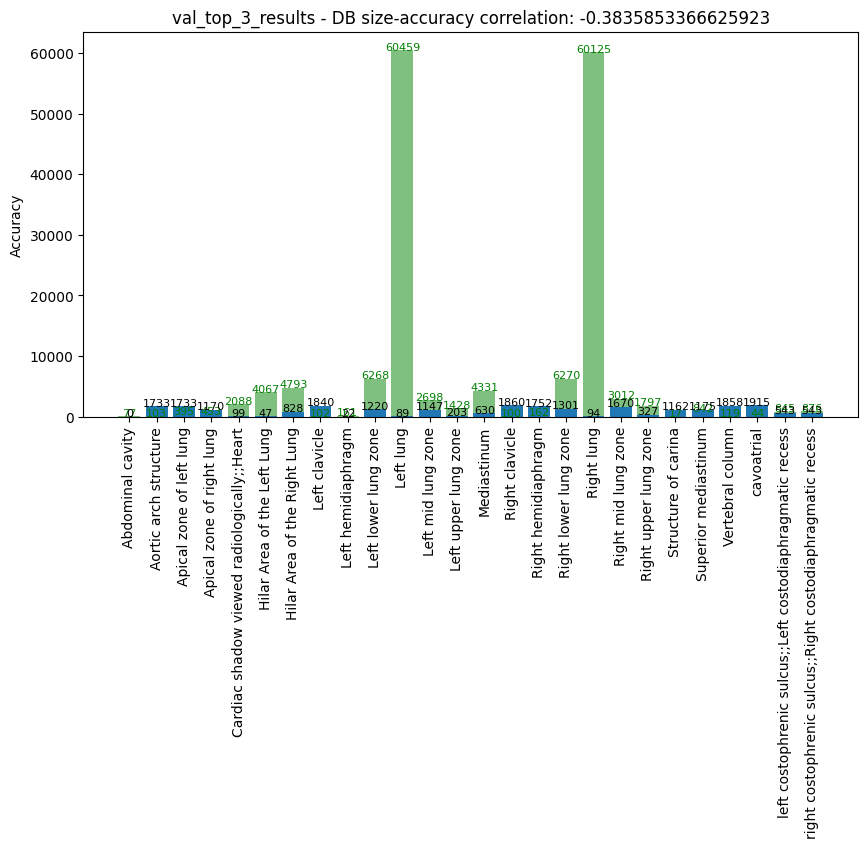

In [38]:
for filename in results_csvs:

    df = pd.read_csv(os.path.join(rag_results_dir, filename)).drop(columns=['Unnamed: 0'])
    total_retrievals = df.shape[0]
    # correct_retrievals = {k: v/total_retrievals for k, v in df.sum(axis=0).to_dict().items() if k in more_than_one}
    correct_retrievals = {k: v for k, v in df.sum(axis=0).to_dict().items() if k in more_than_one}

    plt.figure(figsize=(10,5))    
    plt.bar(count.keys(), count.values(), color='green', alpha=0.5)
    # put number on top of the bars
    for i in range(len(count)):
        plt.text(i, count[list(count.keys())[i]], count[list(count.keys())[i]], ha='center', fontsize=8, color='green')
    plt.bar(correct_retrievals.keys(), correct_retrievals.values())
    # put number on top of the bars
    for i in range(len(correct_retrievals)):
        plt.text(i, correct_retrievals[list(correct_retrievals.keys())[i]], round(correct_retrievals[list(correct_retrievals.keys())[i]], 2), ha='center', fontsize=8)

    # correlation between correct_retrieval_count and count
    corr = pd.Series(correct_retrievals).corr(pd.Series(count))
    plt.title(f"{filename[:-4]} - DB size-accuracy correlation: {corr}")


    # values in vertical text
    # plt.title(filename)
    plt.ylabel("Accuracy")
    plt.xticks(rotation=90)
    results_dir = os.path.join("./results", f'{experiment_name}_epoch_{epoch}_results')
    os.makedirs(results_dir, exist_ok=True)
    plt.savefig(os.path.join(results_dir, f'{filename[:-4]}.png'), bbox_inches="tight")


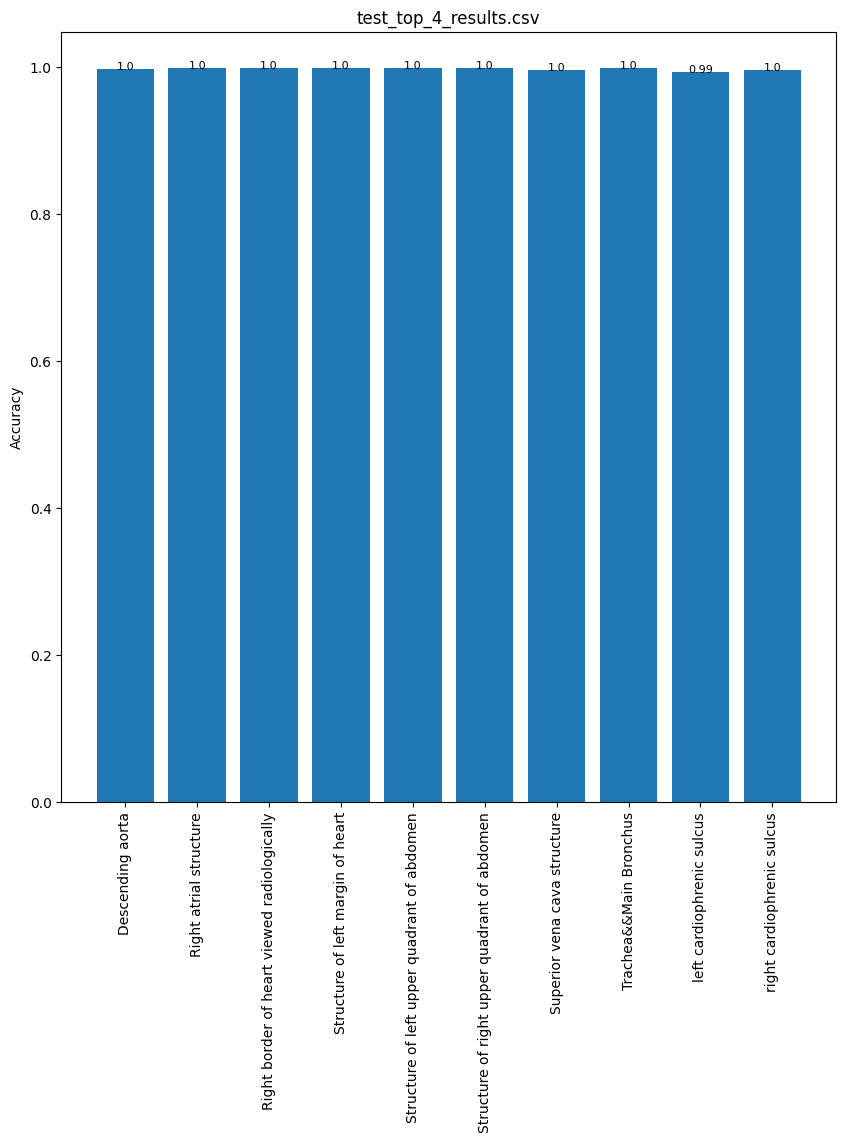

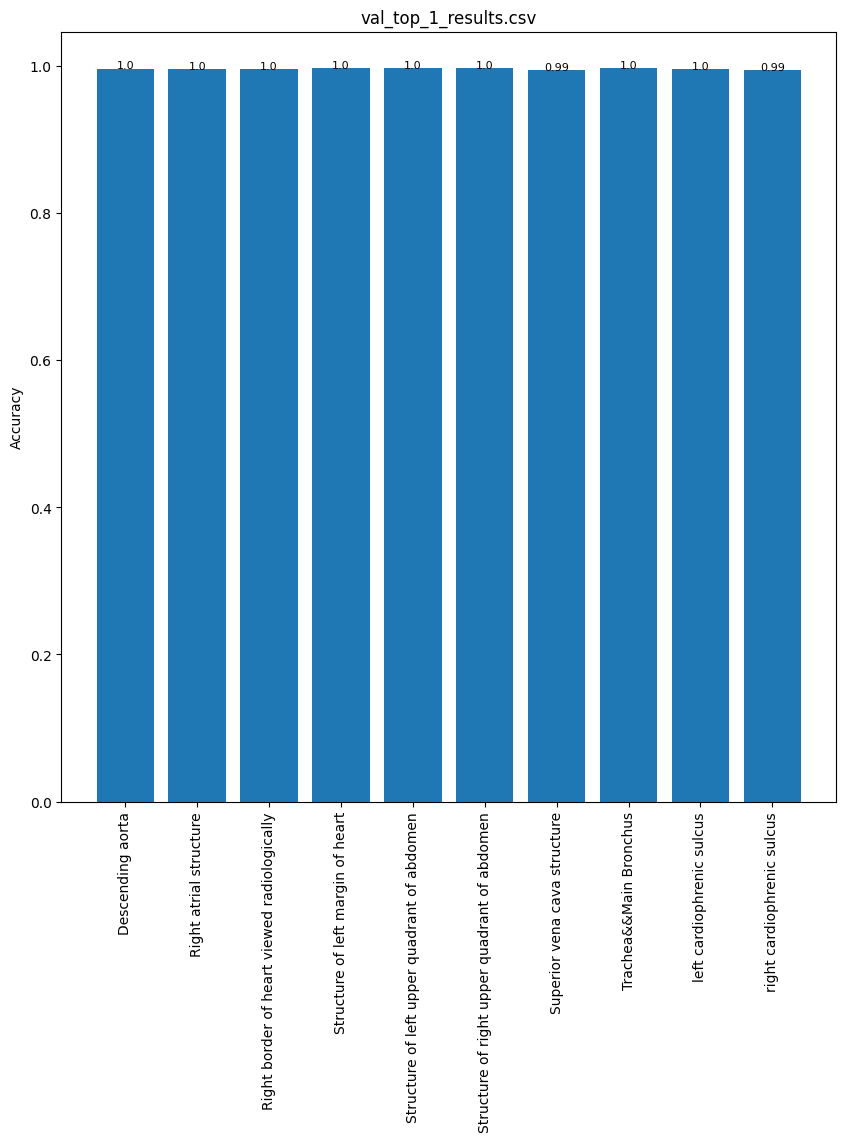

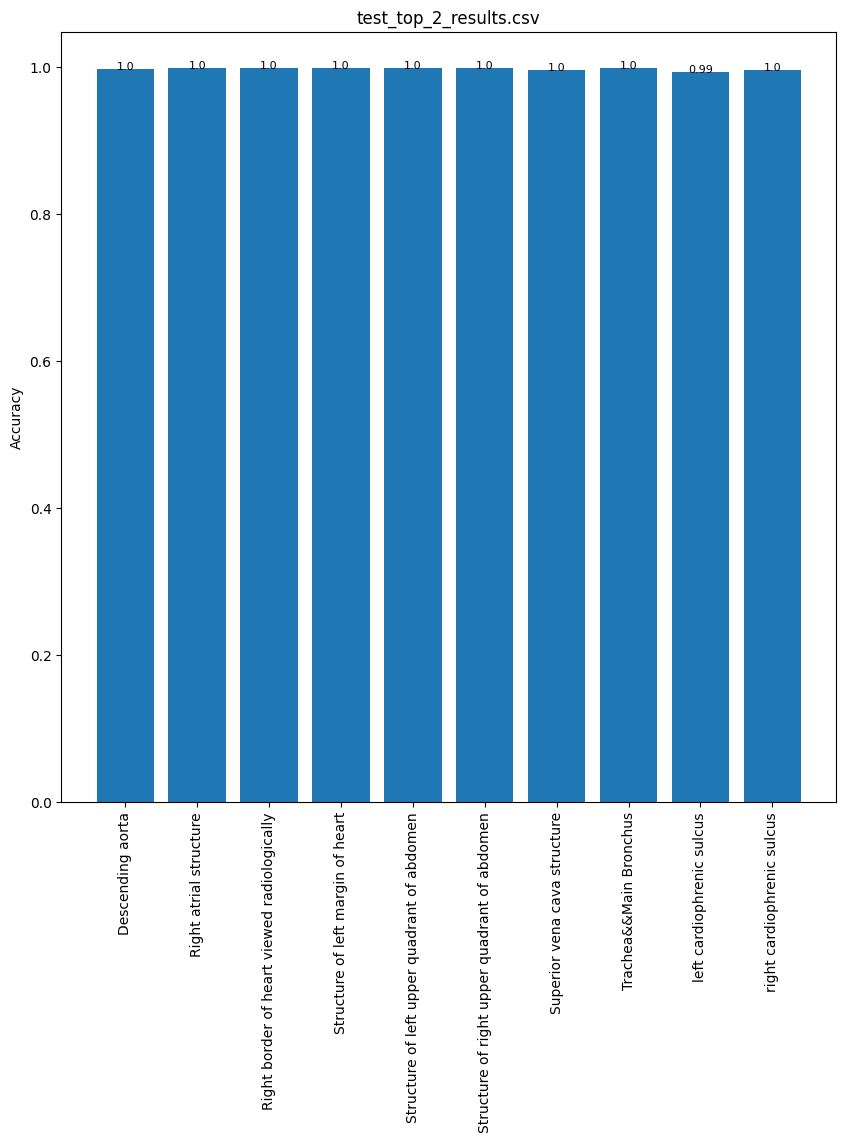

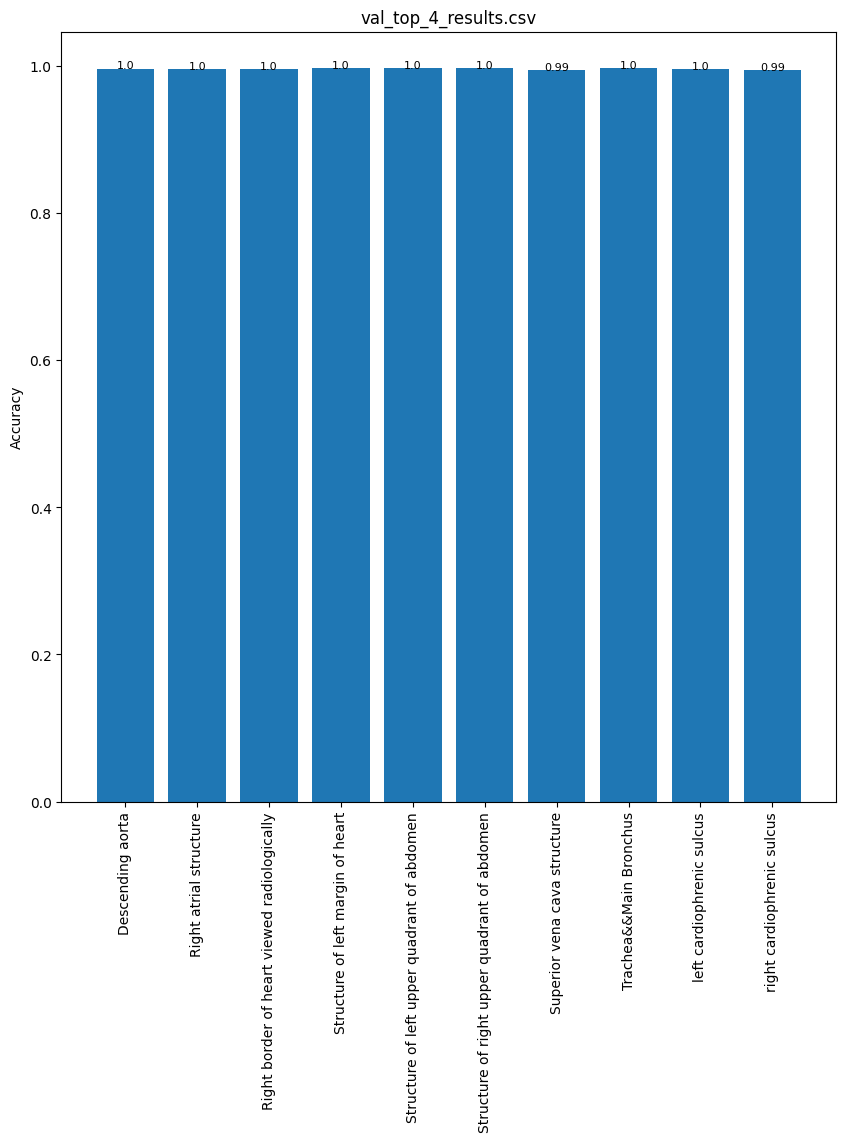

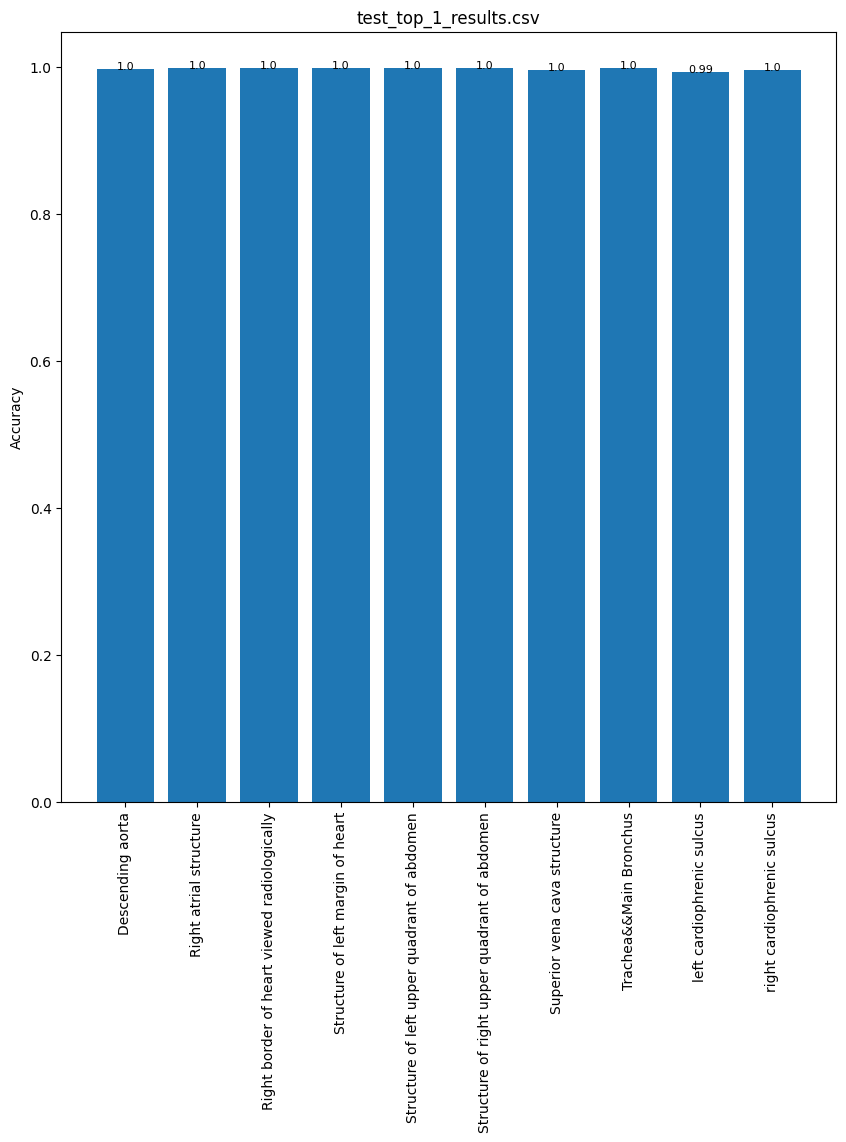

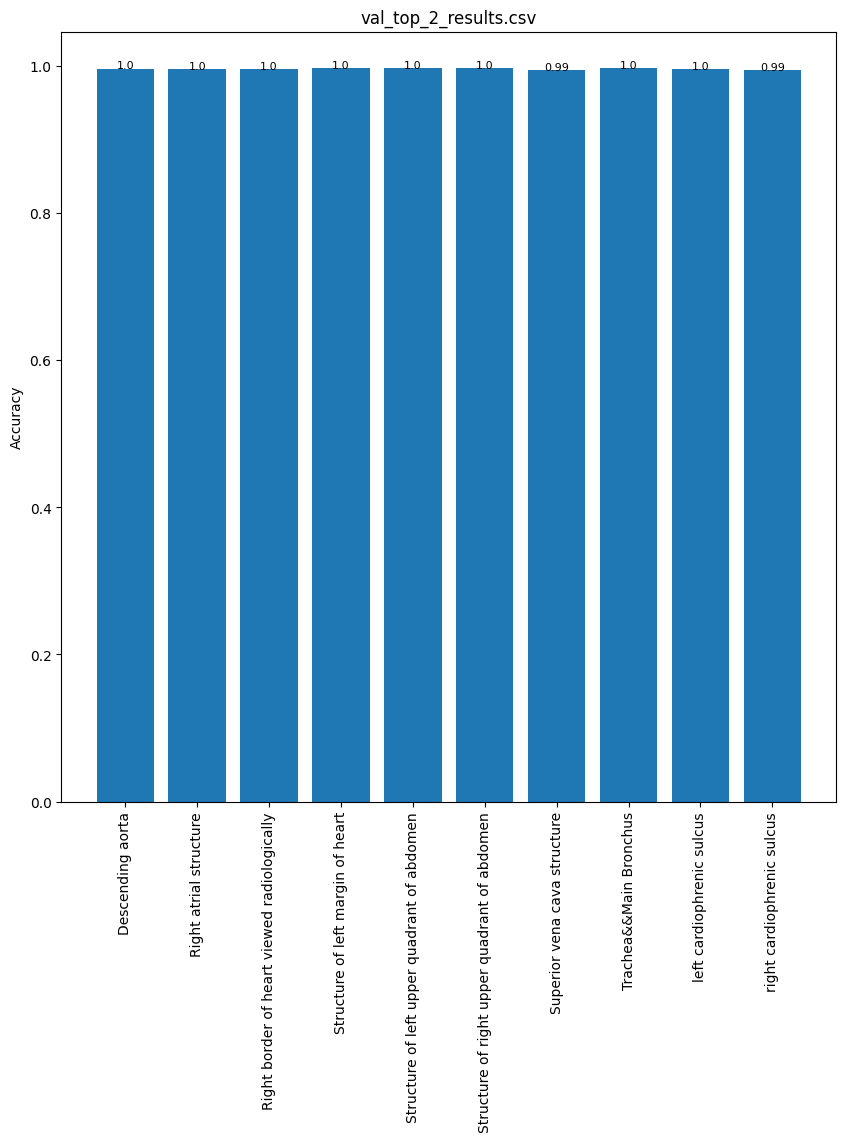

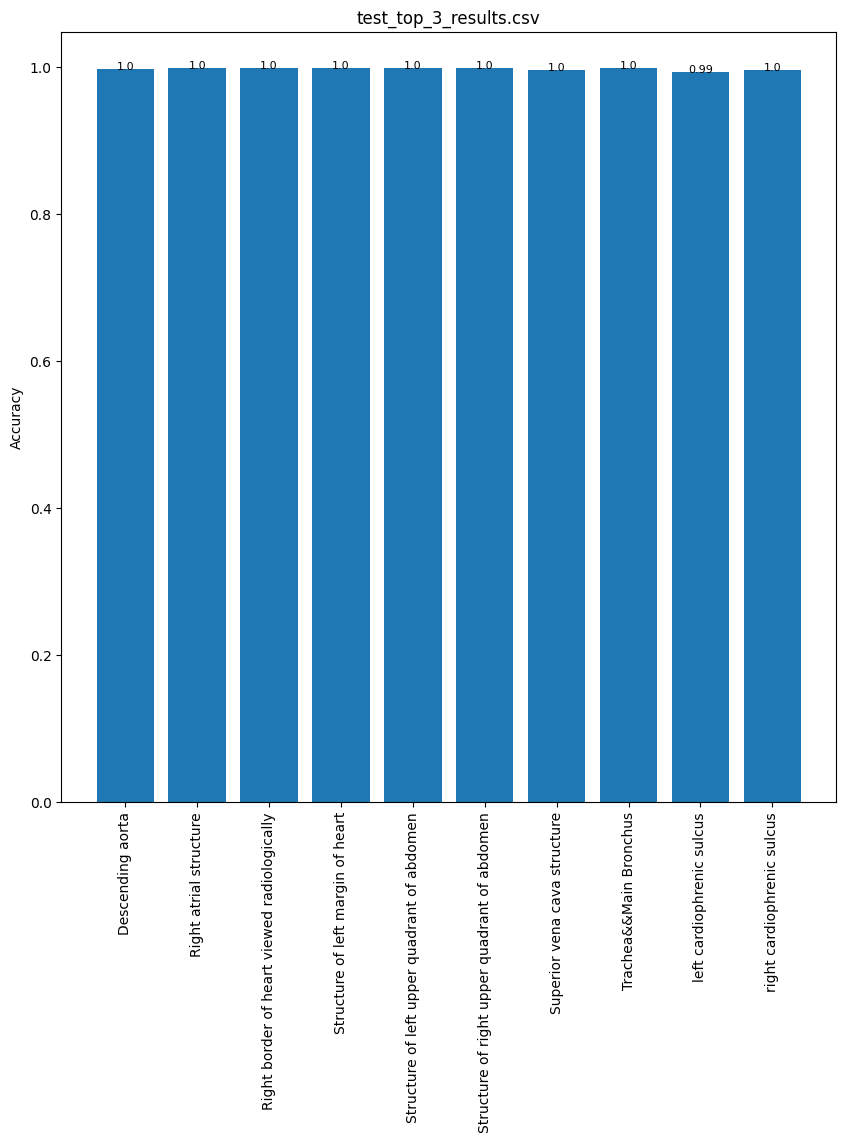

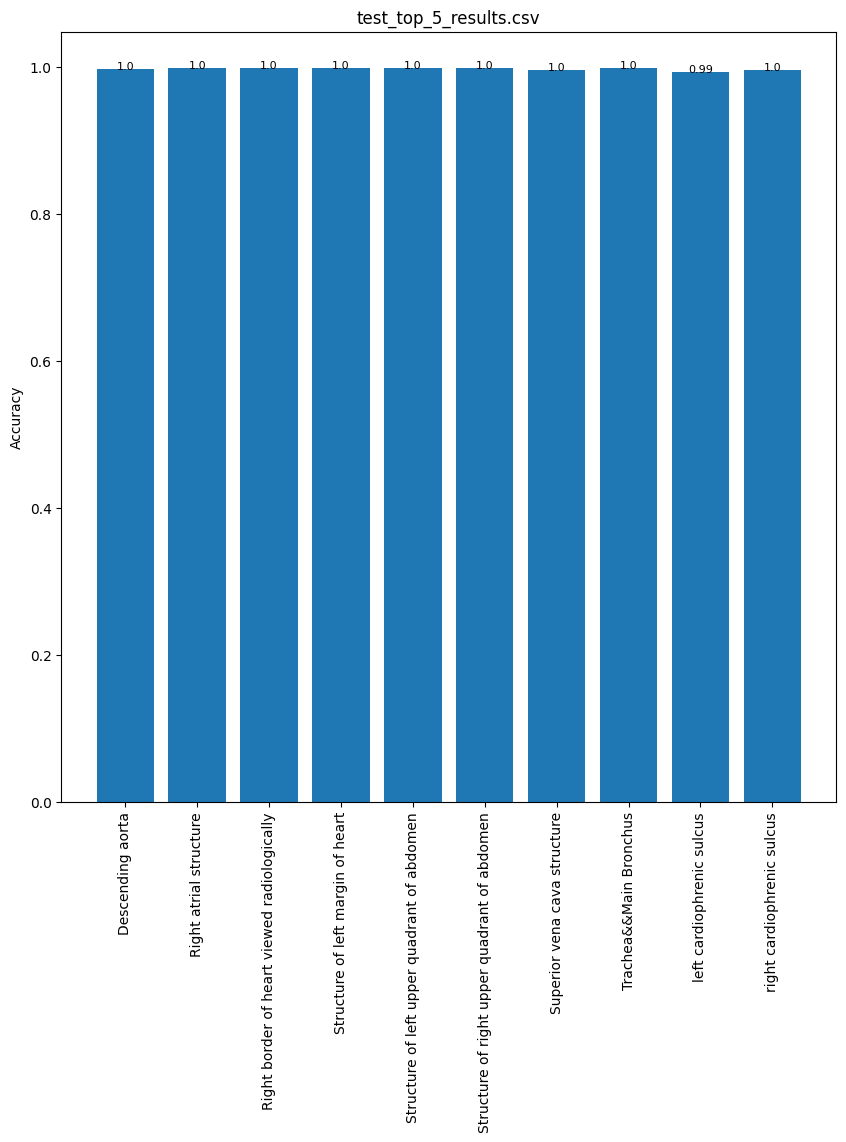

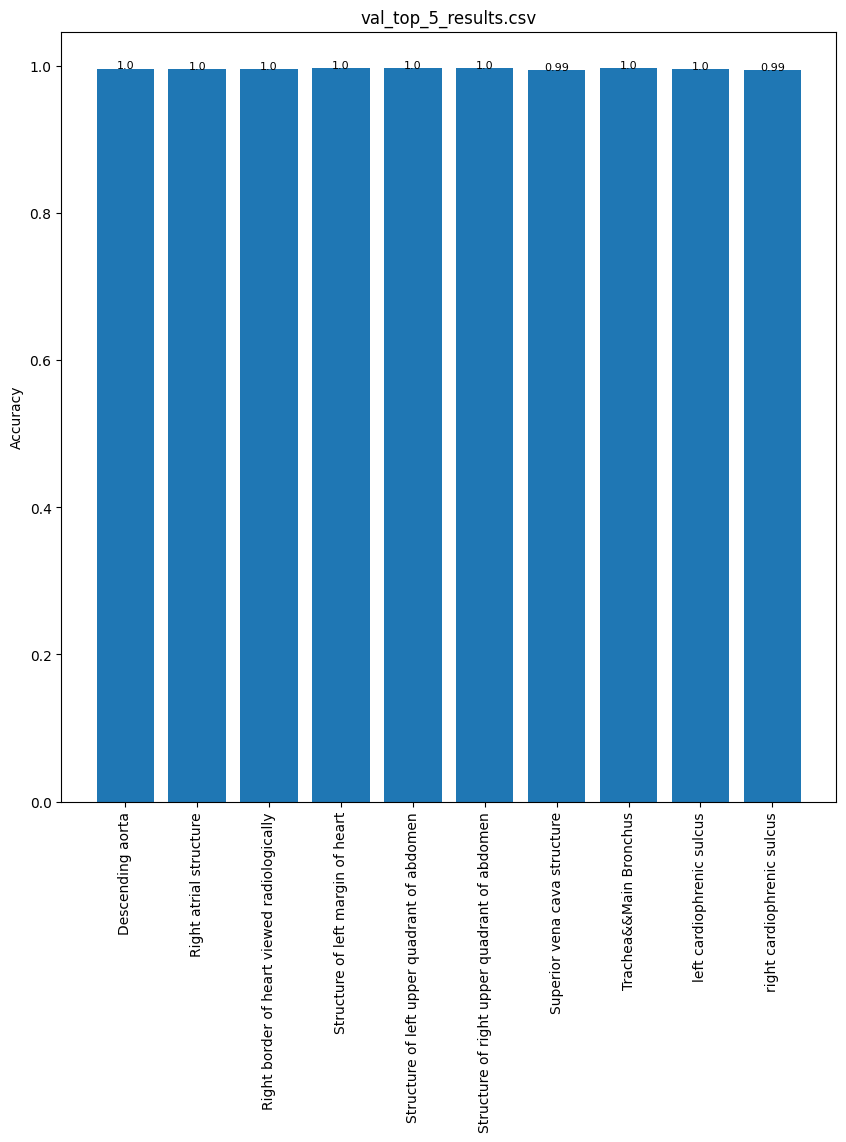

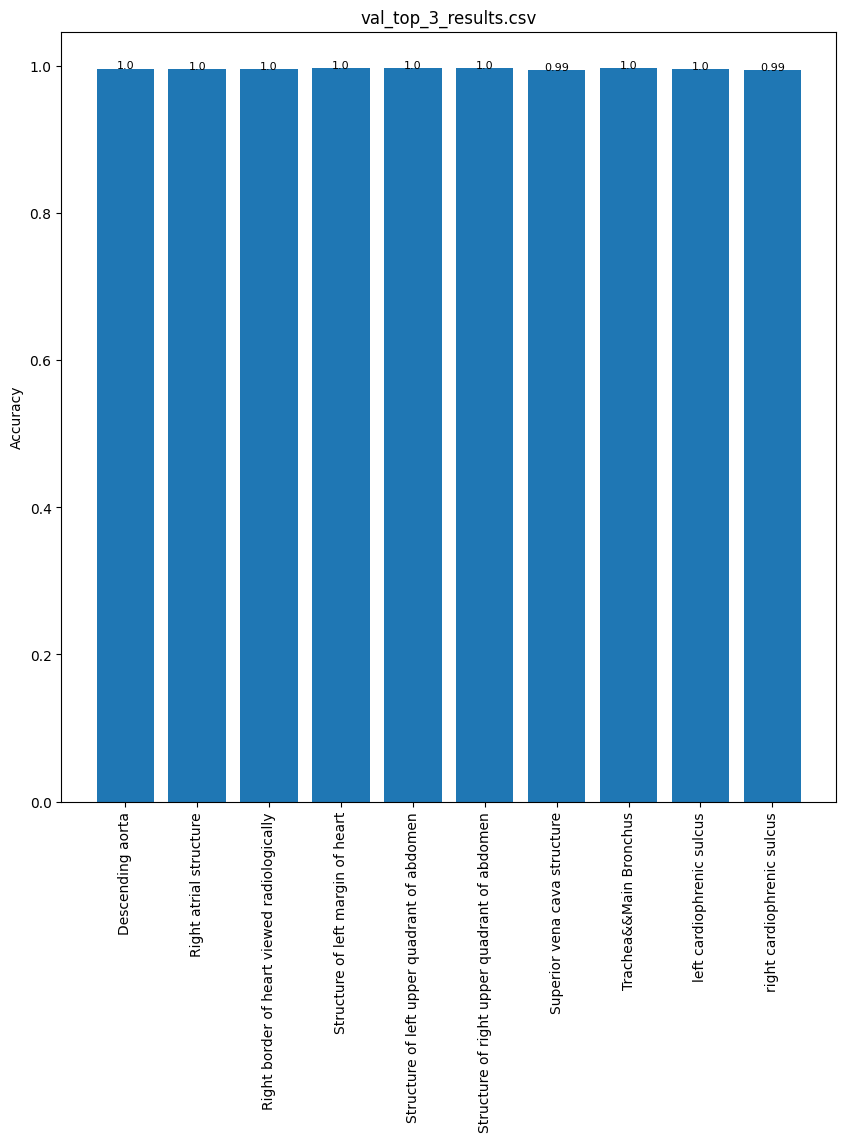

In [7]:
for filename in results_csvs:

    df = pd.read_csv(os.path.join(rag_results_dir, filename)).drop(columns=['Unnamed: 0'])
    total_retrievals = df.shape[0]
    correct_retrievals = {k: v/total_retrievals for k, v in df.sum(axis=0).to_dict().items() if k not in more_than_one}

    plt.figure(figsize=(10,10))    
    plt.bar(correct_retrievals.keys(), correct_retrievals.values())
    # put number on top of the bars
    for i in range(len(correct_retrievals)):
        plt.text(i, correct_retrievals[list(correct_retrievals.keys())[i]], round(correct_retrievals[list(correct_retrievals.keys())[i]], 2), ha='center', fontsize=8)

    # values in vertical text
    plt.title(filename)
    plt.ylabel("Accuracy")
    plt.xticks(rotation=90)
    # os.makedirs("./results/", exist_ok=True)
    # plt.savefig(os.path.join("./results/", f'{filename[:-4]}.png'), bbox_inches="tight")
